<a href="https://colab.research.google.com/github/chennareddie/COVID-19-Detection/blob/main/COVID19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING **LIBRARIES**

In [10]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing import image

UNZIPPING DATASET

In [11]:
zip_path = "/content/covid19.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted!")

Dataset Extracted!


Check folders

In [12]:
print(os.listdir(extract_path))

['Normal', 'Lung Opacity', 'Pneumonia', 'covid']


CONFIGURATION

In [13]:
DATASET_PATH = extract_path
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

CLASSES = ["COVID", "NORMAL", "LUNG_OPACITY", "VIRAL_PNEUMONIA"]


LOAD DATA

In [14]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1568 images belonging to 4 classes.
Found 391 images belonging to 4 classes.


BUILD MODEL (VGG16)

In [15]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze layers

In [16]:
for layer in base_model.layers:
    layer.trainable = False

Custom layers

In [17]:
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(CLASSES), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

TRAIN MODEL

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1188s 24s/step - accuracy: 0.6027 - loss: 1.5607 - val_accuracy: 0.8286 - val_loss: 0.5242
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1175s 24s/step - accuracy: 0.7966 - loss: 0.5362 - val_accuracy: 0.8107 - val_loss: 0.4809
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1182s 24s/step - accuracy: 0.8476 - loss: 0.4212 - val_accuracy: 0.8465 - val_loss: 0.3790
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1164s 24s/step - accuracy: 0.8858 - loss: 0.3405 - val_accuracy: 0.8542 - val_loss: 0.3890
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1164s 24s/step - accuracy: 0.8909 - loss: 0.2925 - val_accuracy: 0.8798 - val_loss: 0.3383
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1201s 25s/step - accuracy: 0.8999 - loss: 0.2789 - val_accuracy: 0.8517 - val_loss: 0.3754
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1160s 24s/step - accuracy: 0.9222 - loss: 0.2369 - val_accuracy: 0.8747 - val_loss: 0.3450
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1162s 24s/step - accuracy: 0.9190 - loss: 0.2375 - val_accu

Save model

In [26]:
model.save("/content/covid_model.h5")

PLOT ACCURACY & LOSS

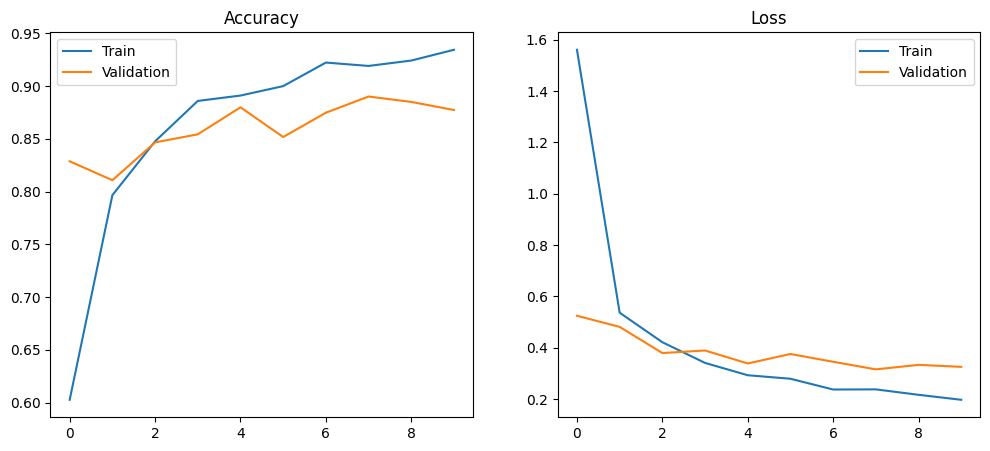

In [20]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

EVALUATE MODEL

In [23]:
loss, acc = model.evaluate(val_data)
print(f"\nValidation Accuracy: {acc*100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 235s 18s/step - accuracy: 0.8772 - loss: 0.3253

Validation Accuracy: 87.72%
